# Function 6: Cake and Stuff
Time to get cooking! You are optimising a cake recipe. There are five ingredients. The outputs correspond to the sum of different objectives: flavor, consistency, calories, waste and cost. Each objective receives negative points by our expert taster. You want this sum to be as close to zero as possible!

In [1]:
import numpy as np
import pandas as pd
from sklearn.gaussian_process import GaussianProcessRegressor
import matplotlib.pyplot as plt

In [2]:
def load_inputs(file_path):
    with open(file_path, "r") as f:
        content = f.read()

    # Make the file a proper list of lists
    content = "[" + content.replace("]\n[", "],[") + "]"

    # Safe eval with restricted globals
    return eval(content, {"array": np.array})


def load_outputs(file_path):
    with open(file_path, "r") as f:
        content = f.read()

    content = "[" + content.replace("]\n[", "],[") + "]"

    return eval(content, {"np": np})


def get_input_points(function_number, file_path="../inputs.txt"):
    if not 1 <= function_number <= 8:
        raise ValueError("Function number must be between 1 and 8")

    data = load_inputs(file_path)
    index = function_number - 1

    inputs = [dataset[index] for dataset in data]
    return np.array(inputs)


def get_output_points(function_number, file_path="../outputs.txt"):
    if not 1 <= function_number <= 8:
        raise ValueError("Function number must be between 1 and 8")

    data = load_outputs(file_path)
    index = function_number - 1

    outputs = [row[index] for row in data]
    return np.array(outputs)

# Load inputs
X = np.load(r'initial_inputs.npy')
y = np.load(r'initial_outputs.npy')


# Get input and outputs from submissions
inputs_array = get_input_points(6)
outputs_array = get_output_points(6)


# Append inputs_f1_array to X
X = np.vstack((X, inputs_array))

# Append outputs_f1_array to Y
y = np.hstack((y, outputs_array))

print("New shape of X:", X.shape)
print("New shape of Y:", y.shape)

New shape of X: (27, 5)
New shape of Y: (27,)


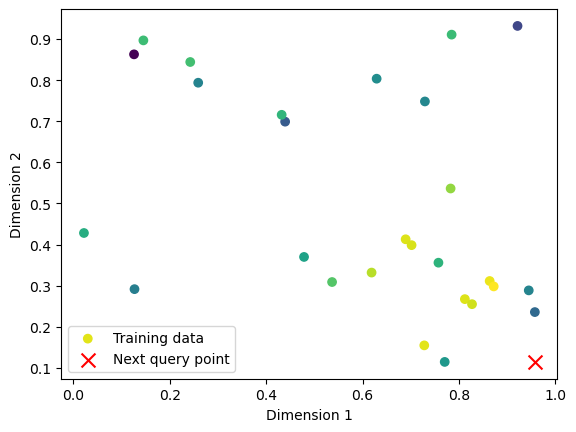

Next Query Point: 0.957740-0.114404-0.978806-0.961656-0.004911


In [3]:
# Maximisation of the function

# Instantiate GPR model
gpr = GaussianProcessRegressor()
gpr.fit(X, y)

# Define grid of points
x1 = np.linspace(X[:, 0].min(), X[:, 0].max(), 30)
x2 = np.linspace(X[:, 1].min(), X[:, 1].max(), 30)
x3 = np.linspace(X[:, 2].min(), X[:, 2].max(), 30)
x4 = np.linspace(X[:, 3].min(), X[:, 3].max(), 30)
x5 = np.linspace(X[:, 4].min(), X[:, 4].max(), 30)
x1, x2, x3, x4, x5 = np.meshgrid(x1, x2, x3, x4, x5)
X_grid = np.column_stack((x1.ravel(), x2.ravel(), x3.ravel(), x4.ravel(), x5.ravel()))

# Predict with GPR
mean, std = gpr.predict(X_grid, return_std=True)

# Calculate UCB
exploration_factor = 1.96
ucb = mean + exploration_factor * std

# Select next query point
next_query_index = np.argmax(ucb)
next_query = X_grid[next_query_index]

# Visualization
fig, ax = plt.subplots()
ax.scatter(X[:,0], X[:,1], c=y, cmap='viridis', label='Training data')
ax.scatter(next_query[0], next_query[1], marker='x', color='red', s=100, label='Next query point')
ax.set_xlabel("Dimension 1")
ax.set_ylabel("Dimension 2")
ax.legend()
plt.show()

# Format the next query point
formatted_next_query = f"{next_query[0]:.6f}-{next_query[1]:.6f}-{next_query[2]:.6f}-{next_query[3]:.6f}-{next_query[4]:.6f}"
print("Next Query Point:", formatted_next_query)